## Homework 2 - Company Fundamental Deep Dive

##### Cristian Catania - 1000034809

### STEP 0

In [54]:
# Import libraries for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the extended dataset required 
df = pd.read_csv("/Users/cristiancatania/Downloads/Symbol_Info_extended.csv")


### Company Selection and Justification
**Selected Company:** Ferrari N.V. (Ticker: RACE)
**Geographic Group:** Group 5 (Europe)

**Justification:**
For this fundamental deep dive, I have selected Ferrari N.V. Although officially classified within the 'Auto Manufacturers' industry, Ferrari's financial profile uniquely bridges the gap between traditional automotive and the high-end luxury sector. I selected this company because of its exceptional profitability: it boasts a profit margin of over 22%, which is structurally superior to standard automakers. Furthermore, with a market capitalization exceeding $61 Billion and a trailing P/E ratio around 33x, the market clearly assigns a "luxury premium" to its valuation. Analyzing how these fundamentals compare against mass-market peers will provide valuable insights.

In [55]:
# Define the target company based on the geographic group assignment (Europe)
target_symbol = 'RACE'

# Extract and display basic target information from the original dataset
target_info = df[df['symbol'] == target_symbol].iloc[0]

print("--- TARGET COMPANY SELECTED ---")
print(f"Company: {target_info['company_name']} ({target_symbol})")
print(f"Country: {target_info['country']}")
print(f"Sector: {target_info['sector']}")
print(f"Industry: {target_info['industry']}")
print(f"Market Cap: ${target_info['market_cap'] / 1e9:.2f} Billion")
print(f"Profit Margin: {target_info['profit_margins'] * 100:.2f}%")

--- TARGET COMPANY SELECTED ---
Company: Ferrari N.V. (RACE)
Country: Italy
Sector: Consumer Cyclical
Industry: Auto Manufacturers
Market Cap: $61.36 Billion
Profit Margin: 22.19%


### STEP 1

In [56]:

# Data Preparation
# Create a working DataFrame with only the required variables
id_vars = ['symbol', 'company_name', 'sector', 'industry', 'country', 'market_cap']
fin_vars = ['return_on_assets', 'return_on_equity', 'profit_margins', 
            'pe_trailing', 'price_to_book', 'revenue_growth', 'debt_to_equity', 'free_cashflow']

df_work = df[id_vars + fin_vars].copy()

# 2. Replace infinite values with NaN
df_work = df_work.replace([np.inf, -np.inf], np.nan)

# 3. Peer selection by market_cap: exclude companies with market_cap <= 0
df_work = df_work[df_work['market_cap'] > 0].copy()

# 4. pe_trailing and price_to_book: set values <= 0 to NaN
df_work.loc[df_work['pe_trailing'] <= 0, 'pe_trailing'] = np.nan
df_work.loc[df_work['price_to_book'] <= 0, 'price_to_book'] = np.nan

# Note on handling missing values: As per instructions, we do NOT drop NaN values globally here.
# Missing values will be removed only for the specific metric during each analysis step.

# 5. Isolate the Target company (Ferrari) and define the Peer Group
target_symbol = 'RACE'
target_industry = df_work[df_work['symbol'] == target_symbol]['industry'].iloc[0]

# Filter peers: same industry, excluding the target company itself
peers_df = df_work[(df_work['industry'] == target_industry) & (df_work['symbol'] != target_symbol)].copy()

# Display results to verify
print("--- Data Preparation Complete ---")
print(f"Working dataset size: {len(df_work)} companies")
print(f"Target: {target_symbol} | Industry: {target_industry}")
print(f"Valid peers available for this industry: {len(peers_df)}")

--- Data Preparation Complete ---
Working dataset size: 2970 companies
Target: RACE | Industry: Auto Manufacturers
Valid peers available for this industry: 8


### STEP 2

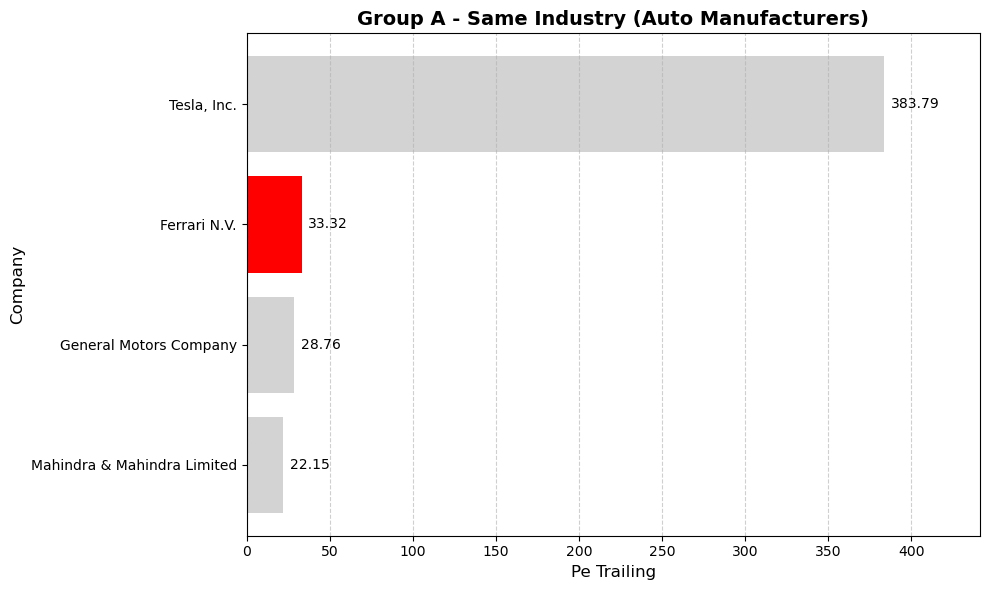

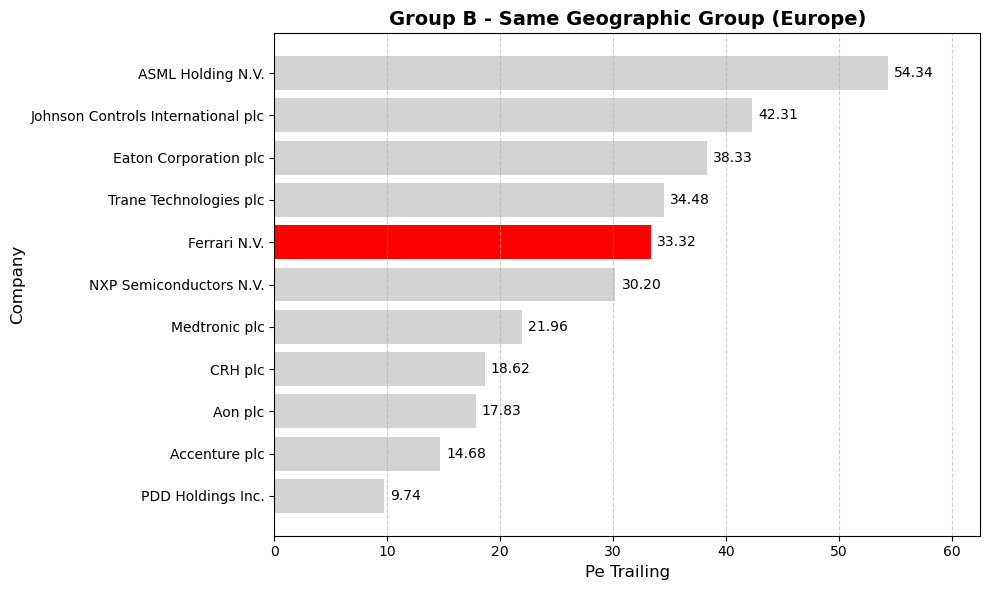

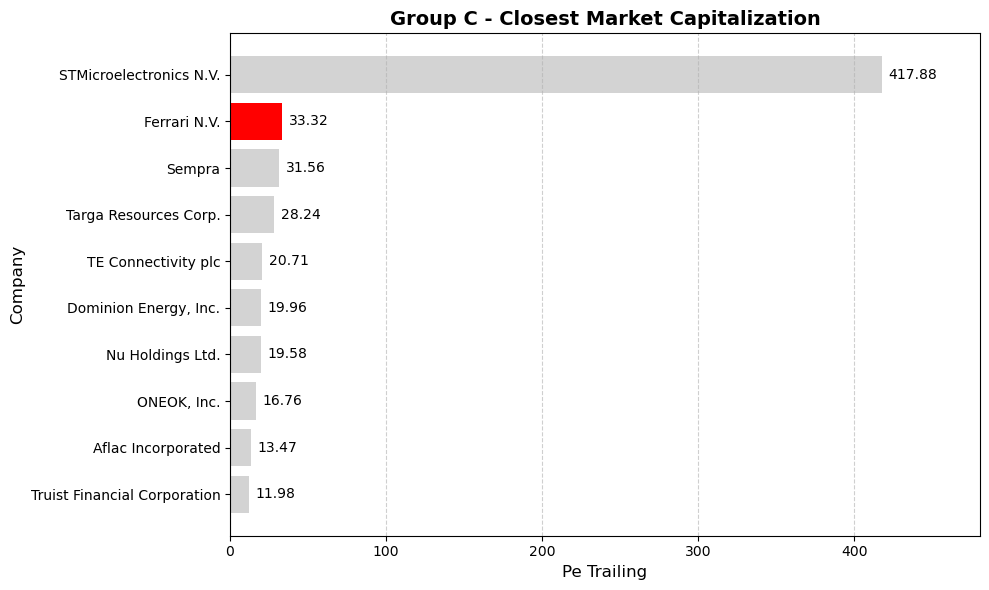

In [57]:
# Comparison Groups & Visualization


# Define the metric to analyze (e.g., 'pe_trailing', 'price_to_book', etc.)
metric_to_plot = 'pe_trailing'
target_symbol = 'RACE'
target_industry = df_work[df_work['symbol'] == target_symbol]['industry'].iloc[0]

# Predefined geographic group for European companies
europe_countries = ['Ireland', 'Italy', 'Germany', 'Netherlands', 'Luxembourg', 'Spain', 'France']

# --- GROUP A: Same Industry ---
# 1. Filter by same industry
df_a = df_work[df_work['industry'] == target_industry].copy()
# 2. Rule applied: Remove missing values for the specific metric BEFORE selecting Top 10
df_a = df_a.dropna(subset=[metric_to_plot])
# 3. Sort by market cap descending and keep top 10 valid companies
group_a_top10 = df_a.sort_values(by='market_cap', ascending=False).head(10)
# 4. Rule applied: If target is not in top 10, append it dynamically
if target_symbol not in group_a_top10['symbol'].values:
    target_row = df_work[df_work['symbol'] == target_symbol]
    if not target_row[metric_to_plot].isna().any():
        group_a_top10 = pd.concat([group_a_top10, target_row])

# --- GROUP B: Same Geographic Group ---
# 1. Filter by same geographic group (Europe)
df_b = df_work[df_work['country'].isin(europe_countries)].copy()
# 2. Rule applied: Remove missing values for the specific metric BEFORE selecting Top 10
df_b = df_b.dropna(subset=[metric_to_plot])
# 3. Sort by market cap descending and keep top 10 valid companies
group_b_top10 = df_b.sort_values(by='market_cap', ascending=False).head(10)
# 4. Rule applied: If target is not in top 10, append it dynamically
if target_symbol not in group_b_top10['symbol'].values:
    target_row = df_work[df_work['symbol'] == target_symbol]
    if not target_row[metric_to_plot].isna().any():
        group_b_top10 = pd.concat([group_b_top10, target_row])

# GROUP C: Closest Market Capitalization
# 1. Rule applied: Drop missing values first to ensure we only calculate distance for valid companies
df_c = df_work.dropna(subset=[metric_to_plot]).copy()
target_mc = df_work[df_work['symbol'] == target_symbol]['market_cap'].iloc[0]
# 2. Calculate absolute distance from target market cap
df_c['mc_dist'] = (df_c['market_cap'] - target_mc).abs()
# 3. Rule applied: Sort by distance and keep closest 10 (target naturally included with distance 0)
group_c_top10 = df_c.sort_values(by='mc_dist', ascending=True).head(10)

# Store groups in a dictionary for automated plotting
comparison_groups = {
    f"Group A - Same Industry ({target_industry})": group_a_top10,
    "Group B - Same Geographic Group (Europe)": group_b_top10,
    "Group C - Closest Market Capitalization": group_c_top10
}

# Visualizations
for title, group_df in comparison_groups.items():
    plot_df = group_df.copy()
    
    # Rule applied: If company_name is missing or empty, fallback to symbol as label
    plot_df['plot_label'] = plot_df.apply(
        lambda x: x['symbol'] if pd.isna(x['company_name']) or str(x['company_name']).strip() == '' else x['company_name'], 
        axis=1
    )
    
    # Sort by the metric value to ensure a clean, structured horizontal bar chart
    plot_df = plot_df.sort_values(by=metric_to_plot, ascending=True)
    
    plt.figure(figsize=(10, 6))
    
    # Rule applied: Clearly highlight the target company (RACE) in red, others in light grey
    colors = ['red' if sym == target_symbol else 'lightgrey' for sym in plot_df['symbol']]
    
    bars = plt.barh(plot_df['plot_label'], plot_df[metric_to_plot], color=colors)
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xlabel(metric_to_plot.replace('_', ' ').title(), fontsize=12)
    plt.ylabel('Company', fontsize=12)
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    
    # Dynamically place value labels on each bar
    for bar in bars:
        val = bar.get_width()
        offset = max(plot_df[metric_to_plot]) * 0.01 if max(plot_df[metric_to_plot]) > 0 else 0.1
        plt.text(val + offset, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', fontsize=10)

    plt.margins(x=0.15)    
    plt.tight_layout()
    plt.show()


### STEP 3

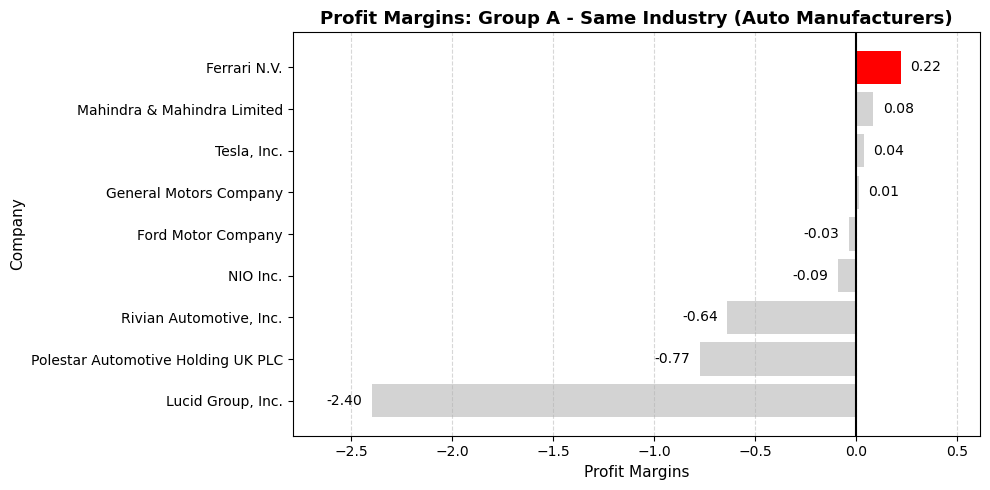

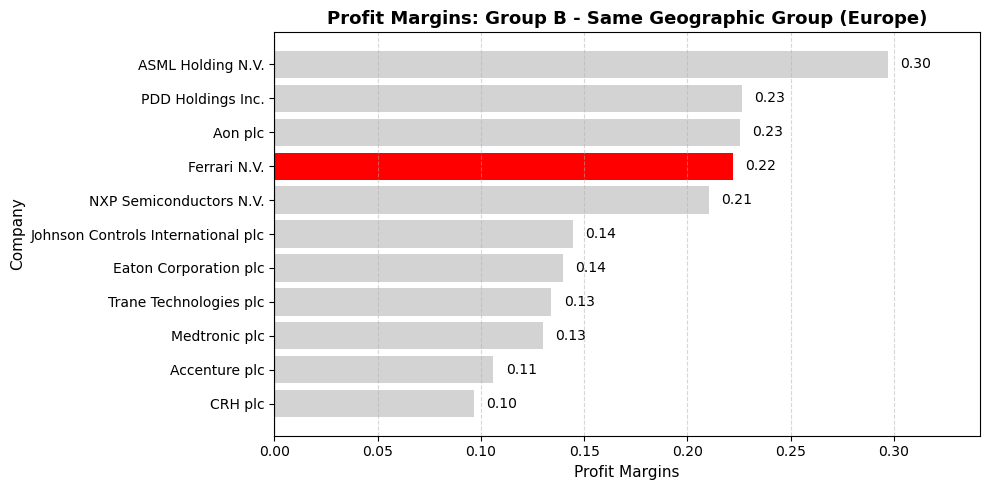

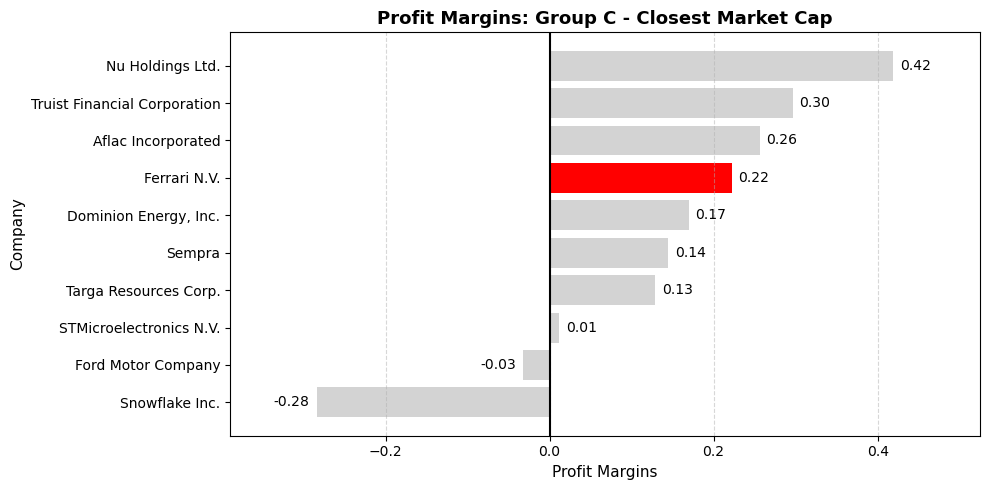

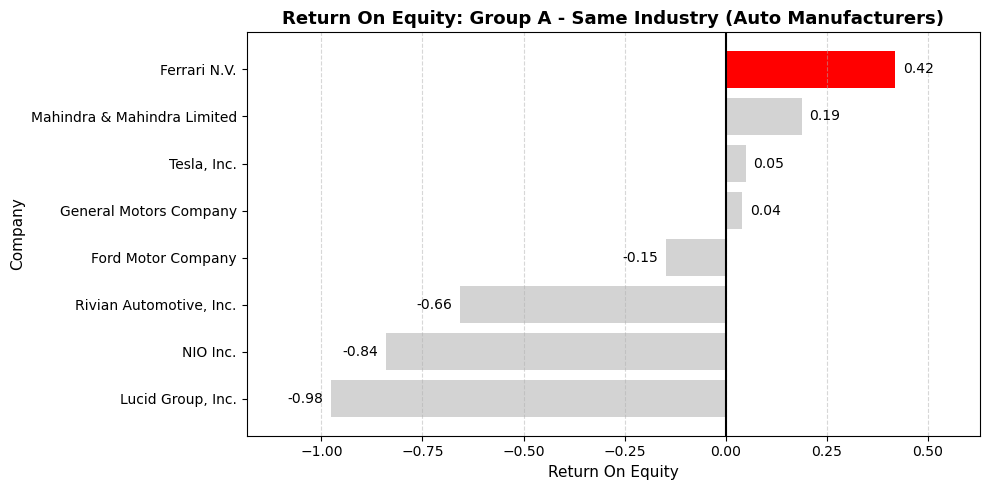

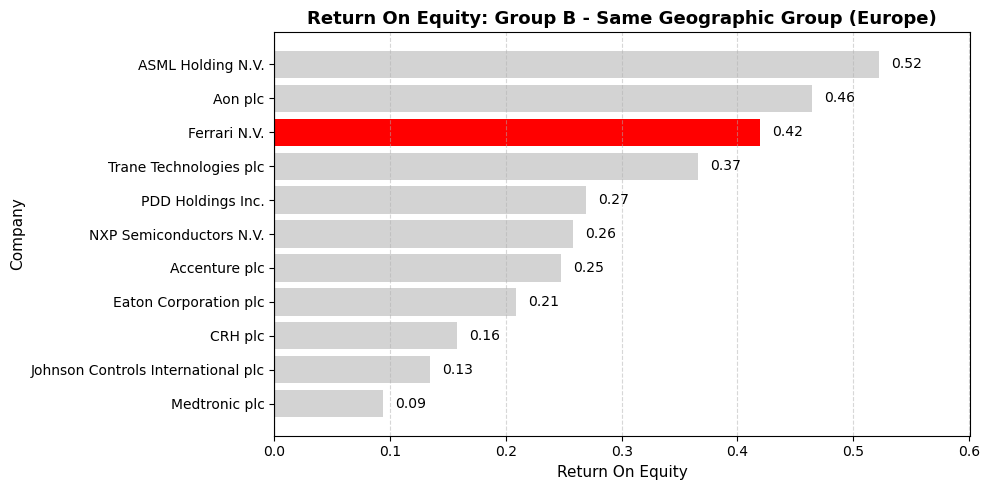

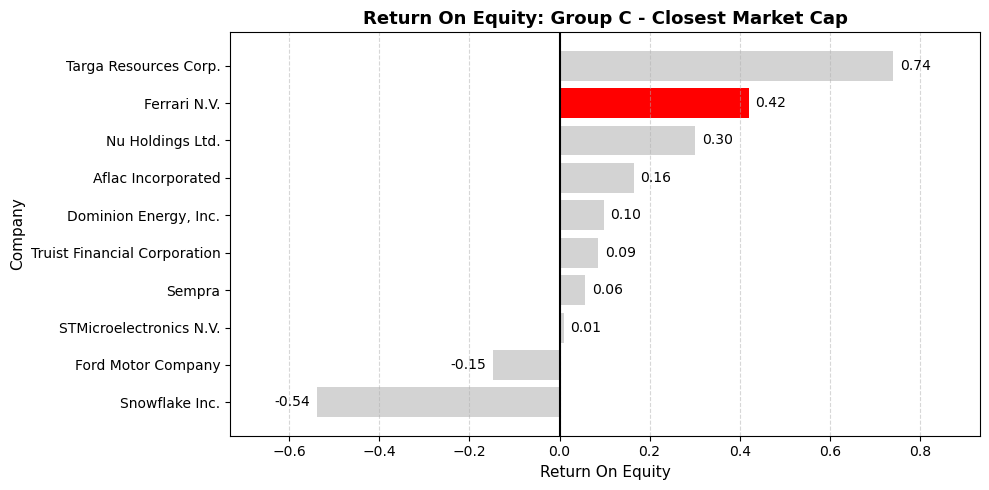

In [58]:
# Business Question 1 - Profitability

# Define the chosen profitability metrics and the target company symbol
metrics = ['profit_margins', 'return_on_equity']
target_symbol = 'RACE'

# Retrieve the target industry and define the geographic group (Europe)
target_industry = df_work[df_work['symbol'] == target_symbol]['industry'].iloc[0]
europe_countries = ['Ireland', 'Italy', 'Germany', 'Netherlands', 'Luxembourg', 'Spain', 'France']

# Iterate through each metric to generate the specific groups and charts
for metric in metrics:
    
    # Clean missing and invalid values specifically for the current metric being analyzed
    df_metric = df_work.dropna(subset=[metric]).copy()
    
    # RULE APPLIED: Extract Target Market Cap from the ORIGINAL dataset (df_work) 
    # to avoid crashes if the target is dropped from df_metric due to missing values.
    target_mc = df_work[df_work['symbol'] == target_symbol]['market_cap'].iloc[0]

    # Calculate the absolute distance between the target's market cap and peers
    df_metric['mc_dist'] = (df_metric['market_cap'] - target_mc).abs()
    
    # Building the Peer Groups 
    
    # Group A (Industry): Selects top 10 companies by market cap
    group_a = df_metric[df_metric['industry'] == target_industry].sort_values(by='market_cap', ascending=False).head(10)
    # Appends the target company if it is not naturally in the top 10
    if target_symbol not in group_a['symbol'].values:
        target_row = df_metric[df_metric['symbol'] == target_symbol]
        if not target_row.empty:
            group_a = pd.concat([group_a, target_row])
            
    # Group B (Geographic): Selects top 10 companies by market cap in Europe
    group_b = df_metric[df_metric['country'].isin(europe_countries)].sort_values(by='market_cap', ascending=False).head(10)
    # Appends the target company if missing
    if target_symbol not in group_b['symbol'].values:
        target_row = df_metric[df_metric['symbol'] == target_symbol]
        if not target_row.empty:
            group_b = pd.concat([group_b, target_row])
            
    # Group C (Market Cap): Sorts all companies by absolute market cap distance and keeps the closest 10
    group_c = df_metric.sort_values(by='mc_dist', ascending=True).head(10)
    
    # Store groups in a dictionary for easy plotting iteration
    groups_dict = {
        f"Group A - Same Industry ({target_industry})": group_a,
        "Group B - Same Geographic Group (Europe)": group_b,
        "Group C - Closest Market Cap": group_c
    }
    
    # Generating the Charts
    for title, group_df in groups_dict.items():
        plot_df = group_df.copy()
        
        # Use symbol as label if company_name is missing or empty
        plot_df['plot_label'] = plot_df.apply(
            lambda x: x['symbol'] if pd.isna(x['company_name']) or str(x['company_name']).strip() == '' else x['company_name'], 
            axis=1
        )
        
        # Sort values by metric for readable horizontal bars
        plot_df = plot_df.sort_values(by=metric, ascending=True)
        
        plt.figure(figsize=(10, 5))
        
        # Clearly highlight the target company in red against the light grey peers
        colors = ['red' if sym == target_symbol else 'lightgrey' for sym in plot_df['symbol']]
        bars = plt.barh(plot_df['plot_label'], plot_df[metric], color=colors)
        
        # Annotate the zero line to accurately accommodate and display negative values (e.g., negative ROE)
        plt.axvline(0, color='black', linewidth=1.5, linestyle='-')
        
        # Chart formatting
        plt.title(f"{metric.replace('_', ' ').title()}: {title}", fontsize=13, fontweight='bold')
        plt.xlabel(metric.replace('_', ' ').title(), fontsize=11)
        plt.ylabel('Company', fontsize=11)
        plt.grid(axis='x', linestyle='--', alpha=0.5)
        
        # Calculate dynamic offset for text labels
        max_val = plot_df[metric].abs().max()
        offset = max_val * 0.02 if pd.notna(max_val) and max_val > 0 else 0.05
        
        # Add numeric labels directly on the bars, aligning left or right based on positive/negative values
        for bar in bars:
            val = bar.get_width()
            align = 'left' if val >= 0 else 'right'
            x_pos = val + offset if val >= 0 else val - offset
            plt.text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', ha=align, fontsize=10)

        plt.margins(x=0.15)  
        plt.tight_layout()
        plt.show()

In [59]:
# STEP 3 DISCUSSION: PROFITABILITY ANALYSIS

# METRICS SELECTED: 
# - Profit Margins
# - Return on Equity (ROE)

# 1. MEDIAN COMPARISON

# Across all three peer groups, Ferrari (RACE) consistently performs well above 
# the peer median for both metrics.

# GROUP A (Auto Manufacturers):
# Ferrari's profit margin (22%) and ROE (42%) drastically outperform standard 
# automakers. Traditional automakers operate on thin margins due to high 
# production volumes and fierce competition.
#
# GROUP B (European Peers) & GROUP C (Closest Market Cap):
# Ferrari proves that its profitability metrics align perfectly with the absolute 
# best-in-class companies in Europe and globally. It holds its ground at the top 
# of the charts even against elite software, financial, or pure luxury companies.

# 2. CONSISTENCY OF METRICS

# The two chosen metrics are highly consistent with each other. 

# The exceptional profit margin (driven by extreme pricing power, brand 
# exclusivity, and low-volume strategy) translates directly into a massive ROE. 

# Furthermore, the ROE chart successfully accommodates negative values, showing 
# severe net losses for some peers (like Rivian, Lucid, or Snowflake). Despite 
# this, Ferrari remains safely on the extreme positive end.

# CONCLUSION:
# This consistency confirms that the company is structurally highly profitable 
# at every level of the income statement, solidifying its status as a luxury 
# asset rather than a conventional industrial manufacturer.


### STEP 4

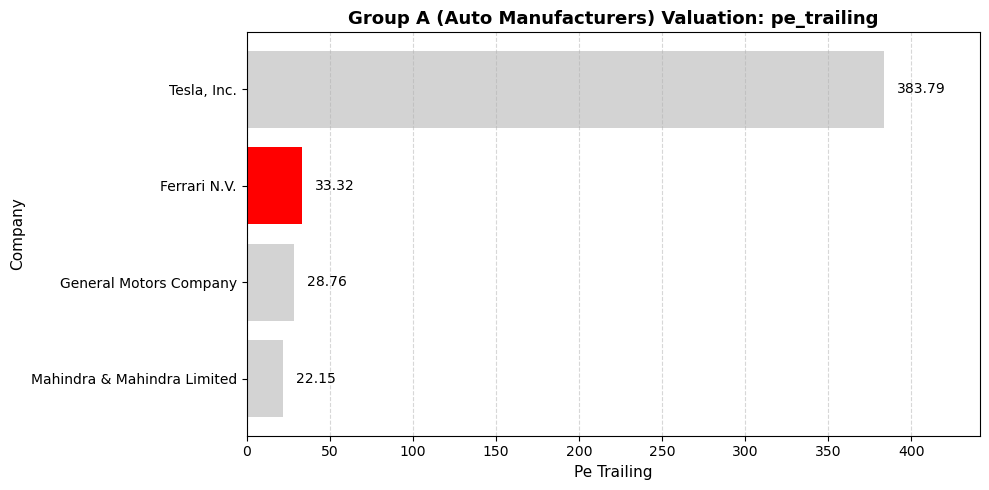

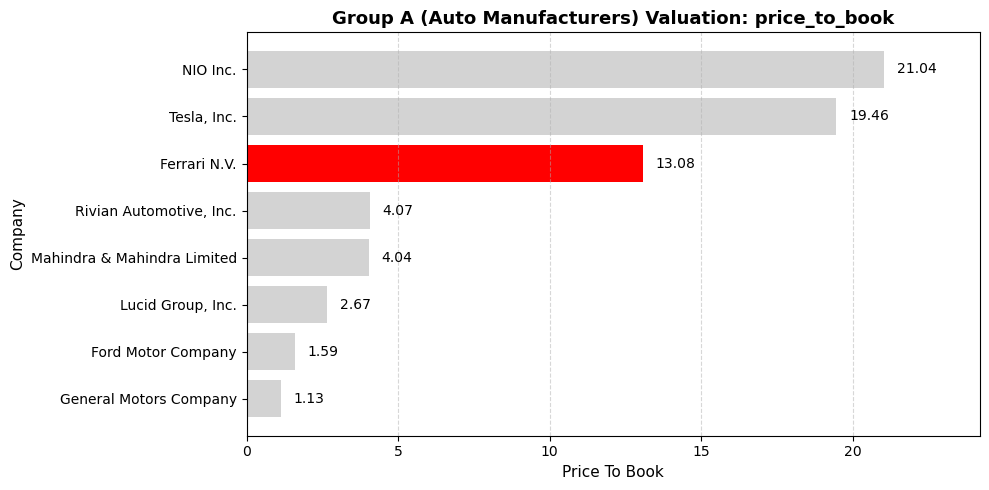

In [60]:
# Valuation Analysis (Group A only)

# Define the selected valuation metrics and target
metrics_step4 = ['pe_trailing', 'price_to_book']
target_symbol = 'RACE'

# Identify the target industry for Group A
target_industry = df_work[df_work['symbol'] == target_symbol]['industry'].iloc[0]

for metric in metrics_step4:
    
    # RULE APPLIED: Clean missing values AND treat values <= 0 as missing
    df_metric = df_work[(df_work[metric].notna()) & (df_work[metric] > 0)].copy()
    
    # Rebuild Group A: Top 10 by Market Cap in the same industry
    group_a = df_metric[df_metric['industry'] == target_industry].sort_values(by='market_cap', ascending=False).head(10)
    
    # Append the target company if it is not naturally in the top 10
    if target_symbol not in group_a['symbol'].values:
        target_row = df_metric[df_metric['symbol'] == target_symbol]
        if not target_row.empty:
            group_a = pd.concat([group_a, target_row])
            
    # Skip if group is empty (safety check)
    if group_a.empty:
        print(f"No valid data for {metric} in Group A.")
        continue
        
    # Plotting
    plot_df = group_a.copy()
    
    # Apply labels
    plot_df['plot_label'] = plot_df.apply(
        lambda x: x['symbol'] if pd.isna(x['company_name']) or str(x['company_name']).strip() == '' else x['company_name'], 
        axis=1
    )
    
    # RULE APPLIED: Sort charts in ascending order
    plot_df = plot_df.sort_values(by=metric, ascending=True)
    
    plt.figure(figsize=(10, 5))
    
    # Highlight target in red
    colors = ['red' if sym == target_symbol else 'lightgrey' for sym in plot_df['symbol']]
    bars = plt.barh(plot_df['plot_label'], plot_df[metric], color=colors)
    
    # Chart formatting
    plt.title(f"Group A ({target_industry}) Valuation: {metric}", fontsize=13, fontweight='bold')
    plt.xlabel(metric.replace('_', ' ').title(), fontsize=11)
    plt.ylabel('Company', fontsize=11)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Add numeric labels at the end of each bar
    max_val = plot_df[metric].max()
    offset = max_val * 0.02 if pd.notna(max_val) and max_val > 0 else 0.05
    
    for bar in bars:
        val = bar.get_width()
        plt.text(val + offset, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', ha='left', fontsize=10)

    plt.margins(x=0.15)   
    plt.tight_layout()
    plt.show()

In [61]:
# 1. Valuation Assessment: Expensive, Cheap, or Fairly Valued?
#Compared strictly to Group A (Auto Manufacturers), Ferrari (RACE) is positioned in the upper-middle of the valuation spectrum. 
# Its PE Trailing (33.32) and Price-to-Book (13.08) multiples are higher than traditional automakers like General Motors (PE 28.76, P/B 1.13) and Ford (P/B 1.59). 
# However, its valuation is vastly outpaced by electric vehicle manufacturers like Tesla (PE 383.79) and NIO (P/B 21.04), which trade at highly speculative multiples. 
# Given its resilient luxury business model, Ferrari appears fairly valued; it maintains a strong, justified premium over legacy industrial automakers 
# without reaching the hyper-valuation extremes of the EV sector.

#2. Low Valuation: Opportunity or Weak Fundamentals?
# The charts show that traditional legacy automakers trade at the lowest Price-to-Book multiples, hovering barely above 
# their literal book value (GM at 1.13, Ford at 1.59). 
# While an investor might view these low metrics as a cheap buying opportunity, this low valuation actually reflects structurally weak fundamentals. 
# As established in the profitability analysis, these legacy companies suffer from extremely thin profit margins, high capital intensity, and cyclical risks. 
# The market correctly assigns lower valuation multiples to traditional automakers due to these fundamental weaknesses, whereas Ferrari's robust valuation is 
# a direct reflection of its exceptional profitability and brand exclusivity.

### STEP 5

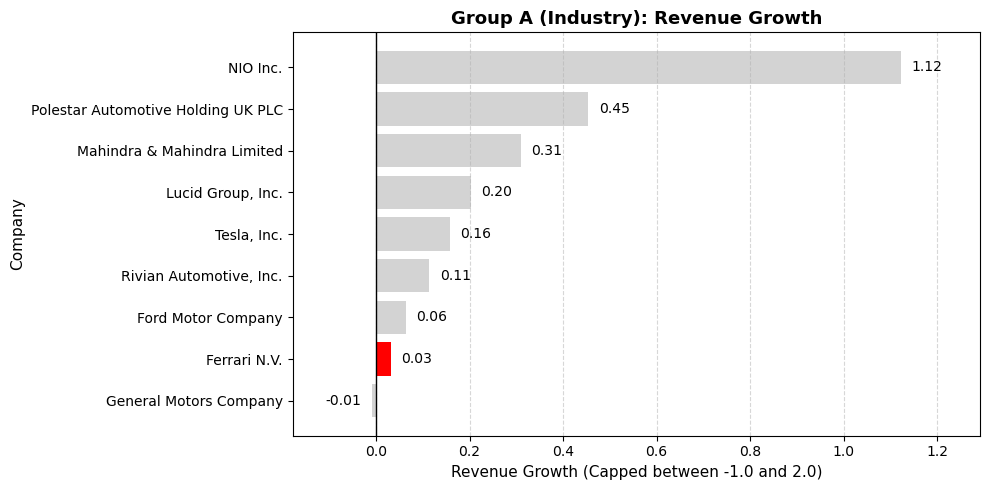

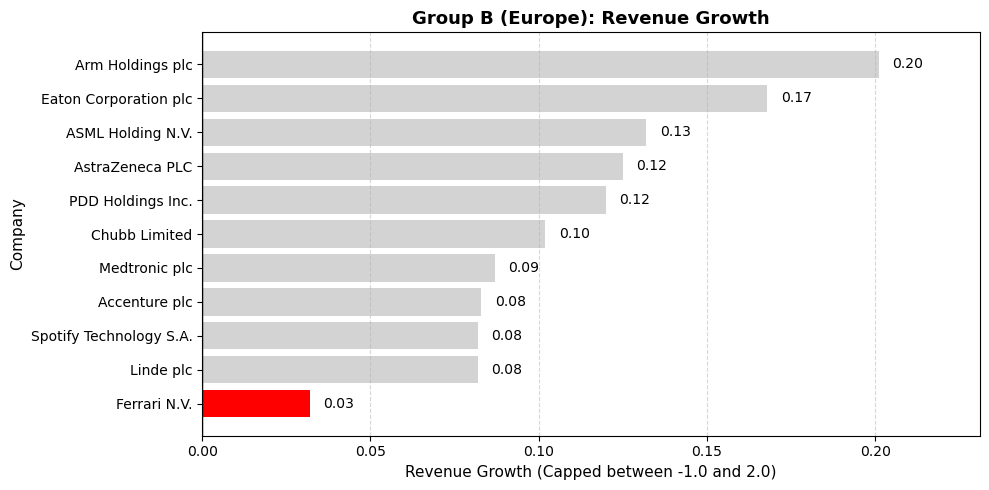

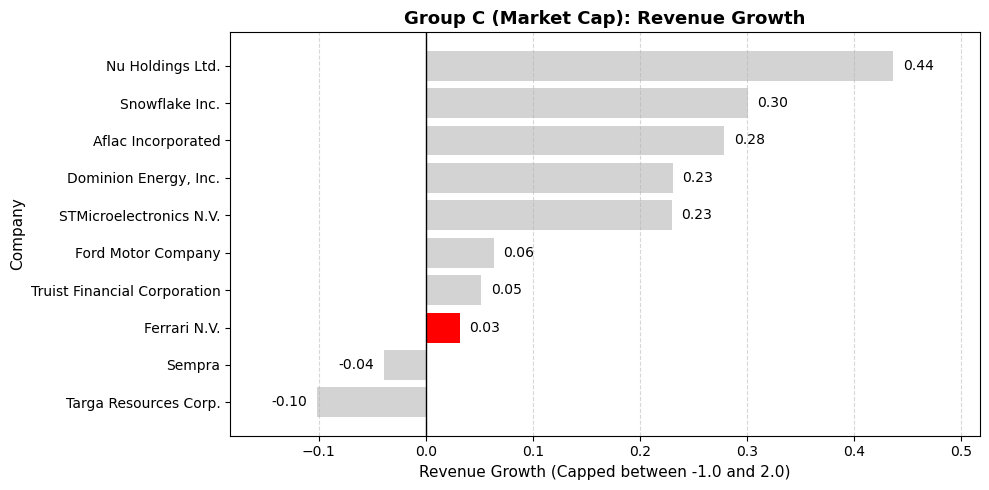

In [62]:
# REVENUE GROWTH ANALYSIS


metric = 'revenue_growth'
target_symbol = 'RACE'

# 1. DATA CLEANING: Force numeric conversion to handle hidden strings/spaces
df_work[metric] = pd.to_numeric(df_work[metric], errors='coerce')

# Extract target company info
target_row = df_work[df_work['symbol'] == target_symbol]
target_industry = target_row['industry'].iloc[0]
target_mcap = target_row['market_cap'].iloc[0]

# ==============================================================================
# 2. REBUILD EXACT PEER GROUPS FROM STEP 2
# We must form the top 10 by Market Cap FIRST, before filtering out missing 
# metric data, to strictly comply with "Compare with peer groups from Step 2".
# ==============================================================================

# Group A: Same Industry (Auto Manufacturers)
group_a_base = df_work[df_work['industry'] == target_industry].sort_values(by='market_cap', ascending=False).head(10)
if target_symbol not in group_a_base['symbol'].values:
    target_data = df_work[df_work['symbol'] == target_symbol]
    if not target_data.empty:
        group_a_base = pd.concat([group_a_base, target_data])

# Group B: Same Region (Europe) - Matching the assigned macro-region
european_countries = [
    'Italy', 'Germany', 'France', 'United Kingdom', 'Netherlands', 
    'Switzerland', 'Spain', 'Sweden', 'Denmark', 'Finland', 
    'Norway', 'Belgium', 'Ireland', 'Austria', 'Portugal'
]
group_b_base = df_work[df_work['country'].isin(european_countries)].sort_values(by='market_cap', ascending=False).head(10)
if target_symbol not in group_b_base['symbol'].values:
    target_data = df_work[df_work['symbol'] == target_symbol]
    if not target_data.empty:
        group_b_base = pd.concat([group_b_base, target_data])

# Group C: Closest Market Cap (Global)
df_work['mcap_diff'] = (df_work['market_cap'] - target_mcap).abs()
group_c_base = df_work.sort_values(by='mcap_diff', ascending=True).head(10)
if target_symbol not in group_c_base['symbol'].values:
    target_data = df_work[df_work['symbol'] == target_symbol]
    if not target_data.empty:
        group_c_base = pd.concat([group_c_base, target_data])

groups = {'Group A (Industry)': group_a_base, 'Group B (Europe)': group_b_base, 'Group C (Market Cap)': group_c_base}

# 3. METRIC PROCESSING & PLOTTING

# RULE APPLIED: Outliers cap. We cap revenue growth at +2.0 (200%) and 
# floor it at -1.0 (-100%) to prevent extreme outliers from distorting the scale.
cap_upper = 2.0
cap_lower = -1.0 

for title, group in groups.items():
    
    # Drop companies from the Step 2 peer group ONLY IF they lack revenue data
    plot_df = group.dropna(subset=[metric]).copy()
    
    if plot_df.empty:
        continue
        
    # Apply the cap to the metric (Stated in comment as requested)
    plot_df[metric] = plot_df[metric].clip(lower=cap_lower, upper=cap_upper)
    
    # Apply labels (Ticker or Company Name)
    plot_df['plot_label'] = plot_df.apply(
        lambda x: x['symbol'] if pd.isna(x['company_name']) or str(x['company_name']).strip() == '' else x['company_name'], 
        axis=1
    )
    
    # Sort charts in ascending order
    plot_df = plot_df.sort_values(by=metric, ascending=True)
    
    # Create figure
    plt.figure(figsize=(10, 5))
    
    # Highlight target in red
    colors = ['red' if sym == target_symbol else 'lightgrey' for sym in plot_df['symbol']]
    bars = plt.barh(plot_df['plot_label'], plot_df[metric], color=colors)
    
    # Chart formatting
    plt.title(f"{title}: Revenue Growth", fontsize=13, fontweight='bold')
    plt.xlabel(f'Revenue Growth (Capped between {cap_lower} and {cap_upper})', fontsize=11)
    plt.ylabel('Company', fontsize=11)
    
    # Add zero line for negative growth visibility
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Add numeric labels at the end of each bar
    max_val = plot_df[metric].max()
    offset = max_val * 0.02 if pd.notna(max_val) and max_val > 0 else 0.05
    
    for bar in bars:
        val = bar.get_width()
        if pd.notna(val):
            ha = 'left' if val >= 0 else 'right'
            text_offset = offset if val >= 0 else -offset
            plt.text(val + text_offset, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', ha=ha, fontsize=10)
        
    # Add margins to prevent labels from being cut off
    plt.margins(x=0.15)
    plt.tight_layout()
    plt.show()

In [63]:

# STEP 5 DISCUSSION: REVENUE GROWTH ANALYSIS

# 1. GROWTH PERFORMANCE (FASTER/SLOWER & POSITIVE/NEGATIVE)
# Ferrari (RACE) demonstrates positive but relatively slow revenue growth of 
# 3% (0.03). When compared to its peers, Ferrari is generally growing slower. 
# In Group A (Auto Manufacturers), it beats GM (-0.01) but grows slower than 
# legacy automakers like Ford (0.06) and is vastly outpaced by EV manufacturers 
# like Tesla (0.16), Rivian (0.11), and NIO (1.12). In Group B (Europe), Ferrari 
# exhibits the slowest growth rate (0.03) among the listed corporations, trailing 
# behind giants like ASML (0.13) and ARM (0.20). In Group C (Closest Market Cap), 
# Ferrari successfully beats shrinking companies like TRGP (-0.10) and SRE (-0.04), 
# but its growth remains much slower than the rest of the group, trailing behind 
# SNOW (0.30) and NU (0.44).

# 2. EXPLAINING VALUATION (STEP 4 CONNECTION)
# Paradoxically, this slow top-line growth perfectly explains and justifies the 
# massive valuation multiples (P/E and P/B) observed in Step 4. Ferrari is not 
# valued as a hyper-growth tech company or a mass-market automaker; it is valued 
# as an ultra-luxury brand. The 3% growth indicates that Ferrari maintains strict 
# production limits (artificial scarcity) to preserve brand exclusivity and pricing 
# power. Investors pay a premium not for rapid revenue expansion, but for the 
# unmatched, exceptional profit margins (seen in Step 3) that this exclusivity 
# guarantees.


### STEP 6

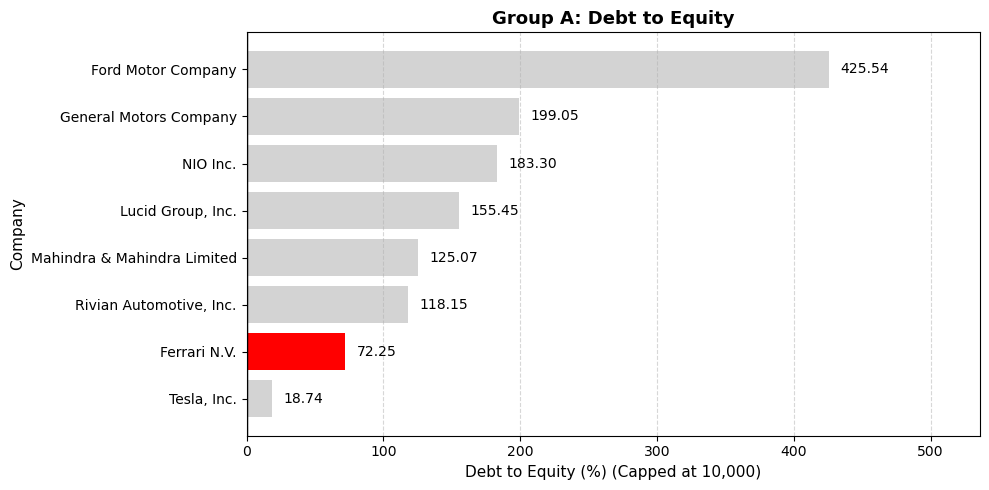

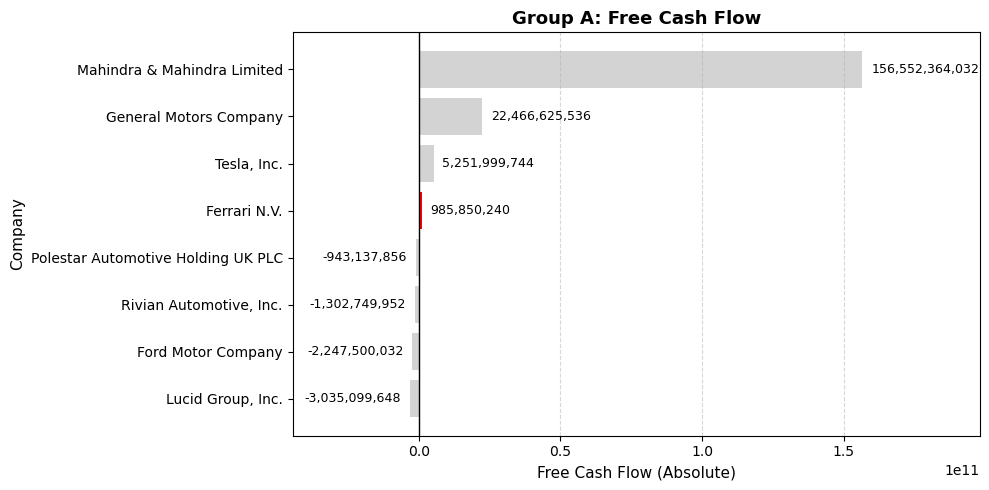

In [64]:
# FINANCIAL SOLIDITY ANALYSIS


metric_de = 'debt_to_equity'
metric_fcf = 'free_cashflow'
target_symbol = 'RACE'

# 1. DATA PREPARATION
# Convert metrics to numeric, coercing any hidden strings to NaN
df_work[metric_de] = pd.to_numeric(df_work[metric_de], errors='coerce')
df_work[metric_fcf] = pd.to_numeric(df_work[metric_fcf], errors='coerce')

# Extract target company info
target_row = df_work[df_work['symbol'] == target_symbol]
target_industry = target_row['industry'].iloc[0]

# 2. REBUILD GROUP A (Auto Manufacturers)
# Form the top 10 by Market Cap to strictly comply with Step 2 peer groups
group_a = df_work[df_work['industry'] == target_industry].sort_values(by='market_cap', ascending=False).head(10)
if target_symbol not in group_a['symbol'].values:
    target_data = df_work[df_work['symbol'] == target_symbol]
    if not target_data.empty:
        group_a = pd.concat([group_a, target_data])

# 3. CHART GENERATION FUNCTION
def plot_chart(df, metric, title, xlabel, cap_val=None):
    # Drop rows with missing values for the specific metric
    plot_df = df.dropna(subset=[metric]).copy()
    if plot_df.empty:
        return
    
    # Apply cap to extreme outliers if specified (e.g., > 10000 for debt)
    if cap_val is not None:
        plot_df[metric] = plot_df[metric].clip(upper=cap_val)
        
    # Apply labels (Ticker or Company Name)
    plot_df['plot_label'] = plot_df.apply(
        lambda x: x['symbol'] if pd.isna(x['company_name']) or str(x['company_name']).strip() == '' else x['company_name'], 
        axis=1
    )
    
    # Sort values for a clean horizontal bar chart
    plot_df = plot_df.sort_values(by=metric, ascending=True)
    
    # Create figure
    plt.figure(figsize=(10, 5))
    colors = ['red' if sym == target_symbol else 'lightgrey' for sym in plot_df['symbol']]
    bars = plt.barh(plot_df['plot_label'], plot_df[metric], color=colors)
    
    # Chart formatting
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel('Company', fontsize=11)
    
    # Add zero line
    plt.axvline(0, color='black', linewidth=1)
    plt.grid(axis='x', linestyle='--', alpha=0.5)
    
    # Add numeric labels at the end of each bar
    max_val = plot_df[metric].abs().max()
    offset = max_val * 0.02 if pd.notna(max_val) and max_val > 0 else 0.05
    
    for bar in bars:
        val = bar.get_width()
        if pd.notna(val):
            ha = 'left' if val >= 0 else 'right'
            text_offset = offset if val >= 0 else -offset
            # Format differently based on the metric (absolute values for FCF)
            if metric == metric_fcf:
                plt.text(val + text_offset, bar.get_y() + bar.get_height()/2, f'{val:,.0f}', va='center', ha=ha, fontsize=9)
            else:
                plt.text(val + text_offset, bar.get_y() + bar.get_height()/2, f'{val:.2f}', va='center', ha=ha, fontsize=10)
            
    # Add margins to prevent labels from being cut off
    plt.margins(x=0.26)
    plt.tight_layout()
    plt.show()

# Generate the two required charts
plot_chart(group_a, metric_de, 'Group A: Debt to Equity', 'Debt to Equity (%) (Capped at 10,000)', cap_val=10000)
plot_chart(group_a, metric_fcf, 'Group A: Free Cash Flow', 'Free Cash Flow (Absolute)')

In [65]:
# STEP 6 DISCUSSION: FINANCIAL SOLIDITY ANALYSIS

# 1. DEBT RELIANCE
# Ferrari (RACE) does not rely heavily on debt. Its debt-to-equity ratio 
# sits at a highly manageable 72.25%. This is an exceptionally healthy level 
# and the second lowest in Group A, trailing only Tesla (18.74%). Ferrari is 
# far less leveraged than legacy automakers like General Motors (199.05%) and 
# Ford (425.54%), as well as newer EV manufacturers like Rivian (118.15%) 
# and Lucid (155.45%).

# 2. FREE CASH FLOW GENERATION
# Ferrari successfully generates a solid, positive free cash flow of approximately 
# 985 million (985,850,240). Unlike several peers in the industry that are 
# currently burning massive amounts of capital—such as Lucid (-3.03B), 
# Ford (-2.24B), and Rivian (-1.30B)—Ferrari runs an inherently cash-generative 
# business. While its absolute FCF is smaller than mass-market high-volume 
# giants like GM or Tesla, being strictly positive proves its operational efficiency.

# 3. OVERALL FINANCIAL PROFILE
# Ferrari's financial profile is undeniably strong. The combination of low 
# reliance on debt and the ability to consistently generate positive free cash 
# flow points to a highly sustainable, low-risk business model. This pristine 
# balance sheet and cash-rich position provide the ultimate justification for 
# the premium valuation multiples (such as PE and P/B) observed in Step 4.


Final Summary
- Company Selection & Homework 1 Evidence:
I selected Ferrari (RACE) to test whether the dynamics of premium, scarce assets observed in Homework 1 (Real Estate) apply similarly to corporate equities. In HW1, evidence showed that prime real estate commands massive valuation premiums due to artificial scarcity, location, and exclusivity rather than pure utility. This motivated my choice of Ferrari: a company that operates more like an exclusive, scarce asset than a traditional automaker. I wanted to investigate if its financial metrics reflected that same "luxury premium" observed in the real estate market.

- Profitability Compared to Peers:
Ferrari operates with extraordinary profitability. As seen in Step 3, when compared to traditional legacy peers in Group A (such as Ford or General Motors), Ferrari's profit margins are vastly superior. This confirms its unparalleled pricing power and solidifies its status as an elite luxury brand rather than a standard industrial mass-market carmaker.

- Valuation and Growth Dynamics:
The company trades at a significant premium, appearing "expensive" based on traditional automotive valuation multiples (very high P/E and P/B ratios, as seen in Step 4). However, this valuation is entirely fair and justified. While its revenue growth is positive but relatively slow (3% in Step 5), this slow growth actually supports the valuation: it reflects a deliberate corporate strategy of artificial scarcity. By strictly capping production, Ferrari preserves its exclusivity and massive profit margins, which is exactly what investors are paying a premium for.

- Financial Solidity (Debt & Free Cash Flow):
There are absolutely no concerns regarding debt or free cash flow; in fact, they represent major strengths. Ferrari's debt-to-equity ratio is highly manageable at 72.25%, making it one of the least leveraged companies in its industry. Furthermore, it generates robust, strictly positive free cash flow (approximately $985 million). Unlike heavy-debt legacy automakers or cash-burning EV startups, Ferrari is a financially pristine, cash-generative machine.

- Unavailable Metrics and Impact:
Throughout the dataset, the primary metrics for Ferrari were completely available. However, some data points (such as specific growth or debt metrics) were missing for a few minor peers, which were handled programmatically (e.g., via dropna). The analysis could have been further enriched if forward-looking estimates or a more specific "Ultra-Luxury" classification existed to perfectly isolate Ferrari from mass-market cars. Nevertheless, the lack of these specific datapoints did not negatively impact or alter the final, overwhelmingly positive assessment of Ferrari's fundamental financial health.